# ML Hold-out Validation (`ml_validate`)

This notebook demonstrates **hold-out validation** with `ml_validate`, which evaluates a **trained** model on an independent validation sample set.

Workflow:

1. **`ml_fit`** — train a model on labelled samples
2. **`ml_validate`** — score the trained model on a validation set; write **`metrics.json`**
3. Returns the same model enriched with validation metadata (ready for **`ml_predict()`** or **`save_ml_model()`**)

For **k-fold cross-validation** on an untrained model spec, see [`06_ml_validation.ipynb`](06_ml_validation.ipynb) (`ml_validate_kfold`).

> **Note:** `validation_set` should normally be an independent RDS prepared offline (e.g. a 20% hold-out split). Here we reuse the public Rondônia samples URL to exercise the API end-to-end.

In [10]:
import json
from pathlib import Path

import openeo  # type: ignore

In [11]:
connection = openeo.connect(url="http://127.0.0.1:8000")
connection.authenticate_basic("brian", "123456")

<Connection to 'http://127.0.0.1:8000/' with BasicBearerAuth>

In [12]:
training_set = (
    "https://github.com/e-sensing/sitsdata/raw/main/data/"
    "samples_deforestation_rondonia.rds"
)
# In production, use a separate hold-out RDS file.
validation_set = training_set

## Fit and validate

Chain `mlm_class_random_forest` → `ml_fit` → `ml_validate`. The validation step must receive the **trained** model from `ml_fit`, not the untrained spec.

In [13]:
process_graph = {
    "rf1": {
        "process_id": "mlm_class_random_forest",
        "arguments": {
            "num_trees": 100,
            "seed": 42,
        },
    },
    "fit1": {
        "process_id": "ml_fit",
        "arguments": {
            "model": {"from_node": "rf1"},
            "training_set": training_set,
            "target": "label",
        },
    },
    "validate1": {
        "process_id": "ml_validate",
        "arguments": {
            "model": {"from_node": "fit1"},
            "validation_set": validation_set,
            "target": "label",
            "scoring": [
                "accuracy",
                "kappa",
                "f1",
                "precision",
                "recall",
            ],
        },
        "result": True,
    },
}

job = connection.create_job(
    process_graph=process_graph,
    title="Random Forest fit + hold-out validation",
    description="Train RF then validate on sample set",
)
job.start_and_wait()
results = job.get_results()

0:00:00 Job '8a934184924bc7f81a2ef3a8f459bc1a': send 'start'
0:00:03 Job '8a934184924bc7f81a2ef3a8f459bc1a': running (progress N/A)
0:00:08 Job '8a934184924bc7f81a2ef3a8f459bc1a': running (progress N/A)
0:00:14 Job '8a934184924bc7f81a2ef3a8f459bc1a': running (progress N/A)
0:00:22 Job '8a934184924bc7f81a2ef3a8f459bc1a': running (progress N/A)
0:00:31 Job '8a934184924bc7f81a2ef3a8f459bc1a': finished (progress N/A)


In [14]:
output_dir = Path("data/outputs_validation_holdout")
results.download_files(output_dir)

[PosixPath('data/outputs_validation_holdout/metrics'),
 PosixPath('data/outputs_validation_holdout/job-results.json')]

## Inspect metrics

`metrics.json` includes overall scores, optional per-class metrics, and a confusion matrix (`method: holdout`).

In [15]:
metrics_file = output_dir / "metrics"
with open(metrics_file) as f:
    metrics = json.load(f)

print(f"Method: {metrics.get('method')}")
print(f"Scoring: {metrics.get('scoring')}")
print("\nOverall:")
print(json.dumps(metrics.get("overall", {}), indent=2))

Method: holdout
Scoring: ['accuracy', 'kappa', 'f1', 'precision', 'recall']

Overall:
{
  "accuracy": 0.9996670551023805,
  "kappa": 0.9996091854496366
}


In [16]:
try:
    import pandas as pd

    by_class = metrics.get("by_class", [])
    if by_class:
        display(pd.DataFrame(by_class).set_index("class").round(4))
except ImportError:
    print(json.dumps(metrics.get("by_class", []), indent=2))

,f1,precision,recall
class,,,
Clear_Cut_Bare_Soil,1.0000,1.0000,1.0000
Clear_Cut_Burned_Area,1.0000,1.0000,1.0000
Clear_Cut_Vegetation,1.0000,1.0000,1.0000
Forest,0.9995,1.0000,0.9990
Mountainside_Forest,1.0000,1.0000,1.0000
Riparian_Forest,0.9992,0.9984,1.0000
Seasonally_Flooded,0.9993,1.0000,0.9986
Water,1.0000,1.0000,1.0000
Wetland,1.0000,1.0000,1.0000


Saved data/outputs_validation_holdout/figures/confusion_matrix.pdf
Saved data/outputs_validation_holdout/figures/confusion_matrix.png


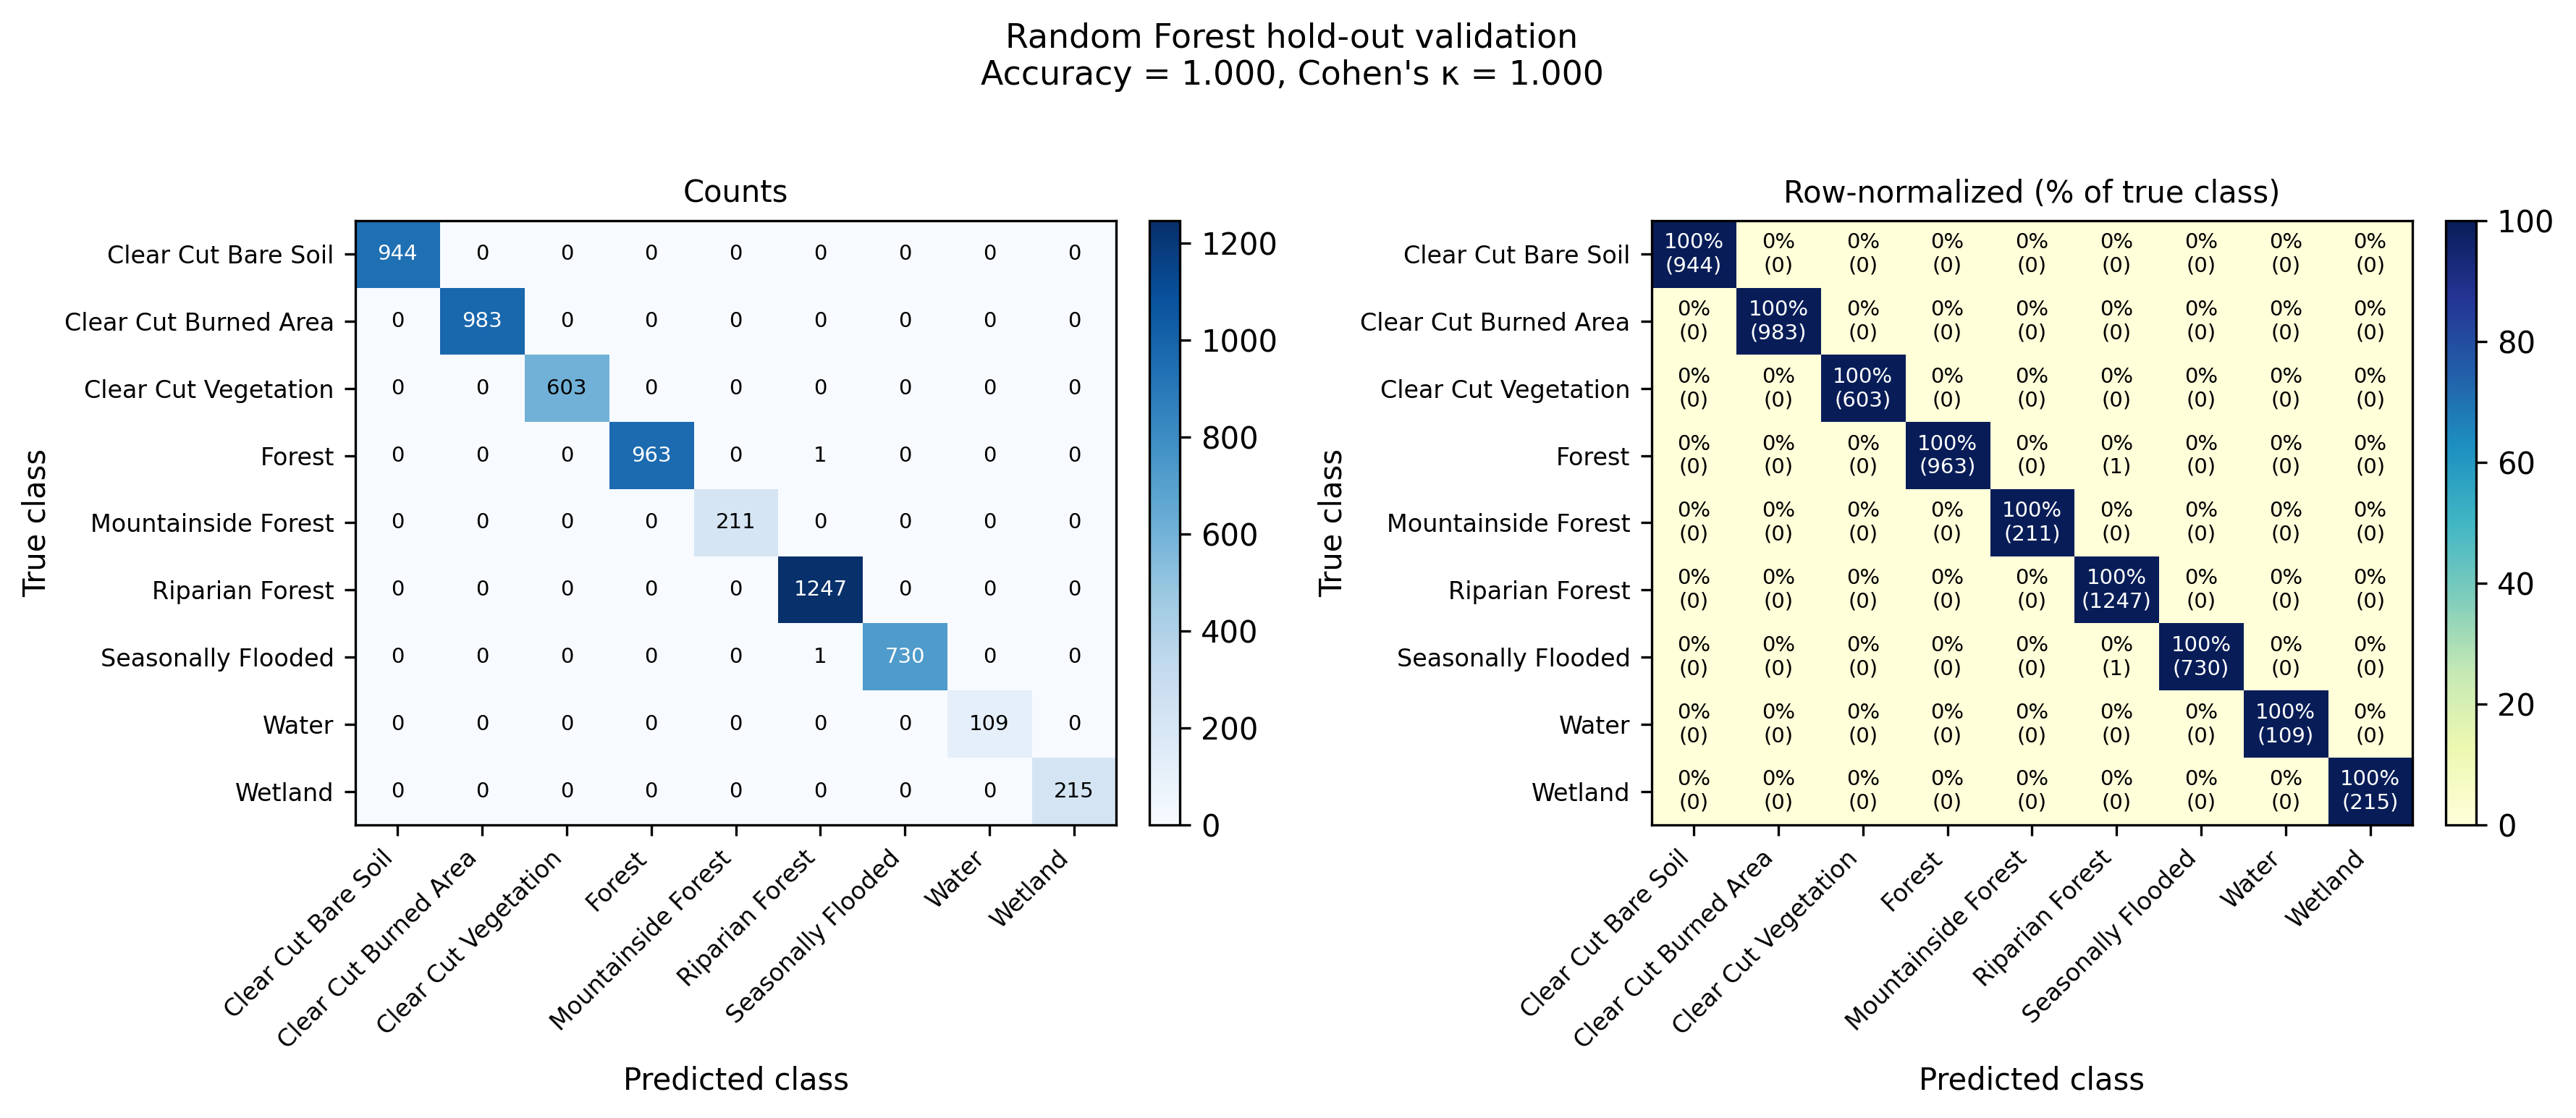

In [17]:
def plot_confusion_matrix_for_paper(cm_dict, *, title, metrics, save_dir=None, dpi=300):
    import matplotlib.pyplot as plt
    import numpy as np

    raw = np.array(cm_dict["matrix"], dtype=float).T
    labels = [name.replace("_", " ") for name in cm_dict["labels"]]
    row_sums = raw.sum(axis=1, keepdims=True)
    norm = np.divide(raw, row_sums, where=row_sums > 0) * 100

    fig, axes = plt.subplots(1, 2, figsize=(12, 5), dpi=dpi)
    for ax, data, annot_fn, cmap, subtitle in (
        (axes[0], raw, lambda i, j: f"{int(raw[i, j])}", "Blues", "Counts"),
        (
            axes[1],
            norm,
            lambda i, j: f"{norm[i, j]:.0f}%\n({int(raw[i, j])})",
            "YlGnBu",
            "Row-normalized (% of true class)",
        ),
    ):
        im = ax.imshow(data, cmap=cmap, aspect="auto")
        ax.set_xticks(range(len(labels)))
        ax.set_yticks(range(len(labels)))
        ax.set_xticklabels(labels, rotation=45, ha="right", fontsize=8)
        ax.set_yticklabels(labels, fontsize=8)
        ax.set_xlabel("Predicted class")
        ax.set_ylabel("True class")
        ax.set_title(subtitle, fontsize=10)
        for i in range(data.shape[0]):
            for j in range(data.shape[1]):
                color = "white" if data[i, j] > (0.55 * data.max()) else "black"
                ax.text(j, i, annot_fn(i, j), ha="center", va="center", color=color, fontsize=7)
        fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

    acc = metrics.get("overall", {}).get("accuracy")
    kappa = metrics.get("overall", {}).get("kappa")
    if acc is not None and kappa is not None:
        title += f"\nAccuracy = {acc:.3f}, Cohen's κ = {kappa:.3f}"
    fig.suptitle(title, fontsize=11, y=1.02)
    fig.tight_layout()

    if save_dir is not None:
        save_dir = Path(save_dir)
        save_dir.mkdir(parents=True, exist_ok=True)
        for ext in ("pdf", "png"):
            path = save_dir / f"confusion_matrix.{ext}"
            fig.savefig(path, bbox_inches="tight", dpi=dpi)
            print(f"Saved {path}")
    return fig


import matplotlib.pyplot as plt

cm = metrics.get("confusion_matrix")
if cm is not None:
    plot_confusion_matrix_for_paper(
        cm,
        title="Random Forest hold-out validation",
        metrics=metrics,
        save_dir=output_dir / "figures",
    )
    plt.show()

## Save validated model

Optionally persist the validated model with `save_ml_model` in the same job graph.

In [18]:
process_graph_save = {
    "rf1": {
        "process_id": "mlm_class_random_forest",
        "arguments": {"num_trees": 100, "seed": 42},
    },
    "fit1": {
        "process_id": "ml_fit",
        "arguments": {
            "model": {"from_node": "rf1"},
            "training_set": training_set,
            "target": "label",
        },
    },
    "validate1": {
        "process_id": "ml_validate",
        "arguments": {
            "model": {"from_node": "fit1"},
            "validation_set": validation_set,
            "scoring": ["accuracy", "kappa", "f1"],
        },
    },
    "save1": {
        "process_id": "save_ml_model",
        "arguments": {
            "data": {"from_node": "validate1"},
            "name": "rf-validated-holdout",
        },
        "result": True,
    },
}

job_save = connection.create_job(
    process_graph=process_graph_save,
    title="Fit, validate, and save RF model",
)
job_save.start_and_wait()
print("Saved model: rf-validated-holdout")

0:00:00 Job '6e2204350c3d48073ca79b69e8948e8f': send 'start'
0:00:03 Job '6e2204350c3d48073ca79b69e8948e8f': running (progress N/A)
0:00:08 Job '6e2204350c3d48073ca79b69e8948e8f': running (progress N/A)
0:00:14 Job '6e2204350c3d48073ca79b69e8948e8f': running (progress N/A)
0:00:22 Job '6e2204350c3d48073ca79b69e8948e8f': running (progress N/A)
0:00:32 Job '6e2204350c3d48073ca79b69e8948e8f': finished (progress N/A)
Saved model: rf-validated-holdout
